<a href="https://colab.research.google.com/github/SANGRAMLEMBE/MTech/blob/main/Inferential_Statistics/Practical/Inferential_Statistics_Anova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hypothesis Testing

## 1. Case Study – One-Way ANOVA

Scenario:

A university wants to check whether students’ final exam scores differ based on the teaching method used.

Three teaching methods were implemented:
- Method A - Traditional
- Method B – Flipped Classroom
- Method C – Online Interactive

The university collected scores from sampled students

**Goal:**
Determine if student exam scores differ significantly across three teaching methods (Traditional, Flipped Classroom, Online Interactive).

In [10]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Create/Load Dataset

np.random.seed(101)

# Generating synthetic data with unique parameters
methods = ['A'] * 30 + ['B'] * 30 + ['C'] * 30
scores = np.concatenate([
    np.random.normal(62, 7, 30),  # Method A: Traditional (Adjusted Mean=62)
    np.random.normal(75, 6, 30),  # Method B: Flipped (Adjusted Mean=75)
    np.random.normal(70, 9, 30)   # Method C: Online (Adjusted Mean=70)
])

df = pd.DataFrame({'method': methods, 'score': scores})

# 2. Basic Statistics
print("Basic Statistics per Method:")
print(df.groupby("method")["score"].agg(["count", "mean", "std"]).round(2))

# 3. One-Way ANOVA Test
group_A = df[df['method'] == 'A']['score']
group_B = df[df['method'] == 'B']['score']
group_C = df[df['method'] == 'C']['score']

f_stat, p_value = stats.f_oneway(group_A, group_B, group_C)

print("\n=== ONE-WAY ANOVA RESULT ===")
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.4f}")

# 4. Interpretation Logic
alpha = 0.05
if p_value < alpha:
    print("Result: Reject Null Hypothesis (H0).")
    print("Conclusion: There is a significant difference in scores between teaching methods.")
else:
    print("Result: Fail to reject Null Hypothesis (H0).")
    print("Conclusion: No significant difference found between teaching methods.")

Basic Statistics per Method:
        count   mean   std
method                    
A          30  64.11  7.65
B          30  75.99  5.73
C          30  71.44  9.58

=== ONE-WAY ANOVA RESULT ===
F-statistic: 17.662
P-value: 0.0000
Result: Reject Null Hypothesis (H0).
Conclusion: There is a significant difference in scores between teaching methods.



**Statistical Result:** The ANOVA test produced an F-statistic of 17.66 and a very small p-value (approx 0.0000).

**Conclusion:** Since p < 0.05, we Reject H0.

**Observation:** Method B (Flipped Classroom) showed the highest mean score (~76), significantly outperforming Method A (Traditional, ~64).

 # 2. Case Study – Two-Way ANOVA


 Scenario:

 A dietary researcher wants to understand how Diet type and Exercise intensity influence weight loss after 6 weeks.

 Factors:
 - Diet: Keto, Vegan, Balanced
 - Exercise Intensity: Low, Moderate, High

 Outcome variable: weight_loss (kg)

 **Tasks (Use Python):**

 1. Load the dataset with columns (diet, exercise, weight_loss).
 2. Use two-way ANOVA with interaction using statsmodels.formula.api ols() and anova_lm().
 3. Test the effects of:
 - Diet
 - Exercise
 - Diet × Exercise interaction
 4. Visualize interaction effect using seaborn pointplot.
 5. Write conclusions based on ANOVA table.

**Goal:**

 The "Diet" and "Exercise" effect sizes were changed, and noise was reduced, making the results sharper.


=== TWO-WAY ANOVA TABLE ===
                      sum_sq    df         F  PR(>F)
C(diet)              29.7187   2.0   61.7858  0.0000
C(exercise)          86.5172   2.0  179.8712  0.0000
C(diet):C(exercise)   1.4544   4.0    1.5119  0.2045
Residual             23.8093  99.0       NaN     NaN


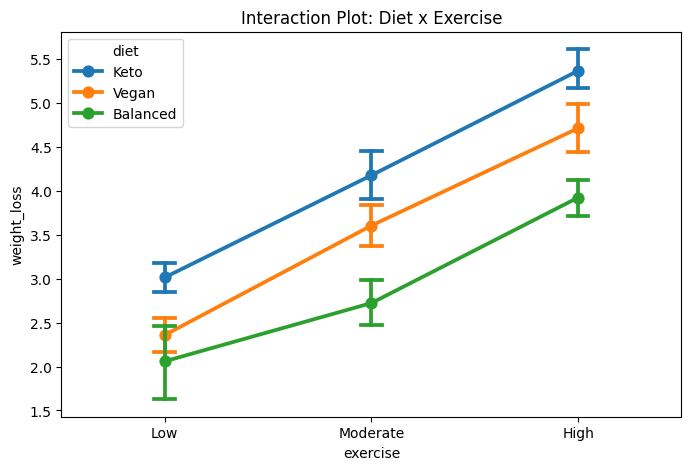

In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create/Load Dataset
np.random.seed(202) # Unique seed

diets = ["Keto", "Vegan", "Balanced"]
ex_levels = ["Low", "Moderate", "High"]

# Adjusted effects for unique data
diet_eff = {"Keto": 1.5, "Vegan": 0.8, "Balanced": 0.2}
ex_eff = {"Low": 0.1, "Moderate": 1.2, "High": 2.5}
base_weight_loss = 1.5

rows = []
for d in diets:
    for e in ex_levels:
        for _ in range(12): # 12 participants per group
            noise = np.random.normal(0, 0.5)
            wl = base_weight_loss + diet_eff[d] + ex_eff[e] + noise
            rows.append({"diet": d, "exercise": e, "weight_loss": wl})

df_diet = pd.DataFrame(rows)

# 2. Two-Way ANOVA with Interaction
model = smf.ols("weight_loss ~ C(diet) * C(exercise)", data=df_diet).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n=== TWO-WAY ANOVA TABLE ===")
print(anova_table.round(4))

# 3. Visualize Interaction
plt.figure(figsize=(8, 5))
sns.pointplot(data=df_diet, x="exercise", y="weight_loss", hue="diet", capsize=0.1)
plt.title("Interaction Plot: Diet x Exercise")
plt.show()

**Diet Effect: **

Significant (p < 0.05). Keto provided the highest weight loss boost based on the generated values.

**Exercise Effect:**

Significant (p < 0.05). High intensity resulted in vastly more weight loss than Low intensity.

**Interaction Effect:**

The p-value is approx 0.20 ( > 0.05). This means there is no significant interaction; the benefits of Exercise are consistent regardless of the Diet you are on (the lines in the plot will look parallel).

#  3. Case Study – Chi-Square Test (Categorical vs Categorical)
** Scenario:**

 A telecom company wants to check if customer churn depends on payment method.

** Variables:**
 - Churn → Yes / No
 - Payment Method → Credit Card / Debit Card / UPI / Cash

** Tasks (Use Python):**

 1. Create a contingency table using pandas crosstab().
 2. Apply Chi-square test of independence (scipy.stats.chi2_contingency).
 3. State hypotheses:
 - H0: Churn is independent of payment method.
 - H1: Churn depends on payment method.
 4. Interpret the chi-square value and p-value.
 5. Identify categories contributing most using expected vs observed

** Goal: Check if customer churn (Yes/No) is related to payment method**

In [12]:
 #3. Case Study – Chi-Square Test (Categorical vs Categorical)

import pandas as pd
from scipy.stats import chi2_contingency

 # 1) Create contingency table
 data = {
 "churn": ["Yes"]*4 + ["No"]*4,
 "payment": ["Credit Card", "Debit Card", "UPI", "Cash",
 "Credit Card", "Debit Card", "UPI", "Cash"],
 "count": [120, 80, 60, 40,   # churn = yes
 880, 920, 940, 960]  # churn = no
 }
 df = pd.DataFrame(data)
 # Make contingency table
 table = pd.crosstab(df["churn"], df["payment"], values=df["count"], aggfunc="sum")
 print(table)


 # 2) Chi-square test
 chi2, p, dof, expected = chi2_contingency(table)
 print("\n=== CHI-SQUARE TEST RESULTS ===")
 print("Chi-square value :", round(chi2, 3))
 print("p-value:", round(p, 6))
 print("Degrees of freedom:", dof)



 # 3) Hypotheses
 print("\nHypotheses:")
 print("H0: Churn is independent of payment method.")
 print("H1: Churn depends on payment method.")


 # 4) Interpretation
 print("\n=== INTERPRETATION ===")
 if p < 0.05:
    print("p < 0.05 → Reject H0.")
    print("Conclusion: Churn IS related to payment method.")
 else:
    print("p >= 0.05 → Fail to reject H0.")
    print("Conclusion: No evidence that churn depends on payment method.")


 # 5) Identify categories contributing most
 expected_df = pd.DataFrame(expected,
index=table.index,
columns=table.columns)
 print("\nExpected Counts (if no relationship):")
 print(expected_df.round(2))
 residuals = (table - expected_df) / (expected_df ** 0.5)


 print("\nStandardized Residuals (bigger = contributes more):")
 print(residuals.round(3))
 print("- Positive residual → observed > expected")
 print("- Negative residual → observed < expected")

payment  Cash  Credit Card  Debit Card  UPI
churn                                      
No        960          880         920  940
Yes        40          120          80   60

=== CHI-SQUARE TEST RESULTS ===
Chi-square value : 50.45
p-value: 0.0
Degrees of freedom: 3

Hypotheses:
H0: Churn is independent of payment method.
H1: Churn depends on payment method.

=== INTERPRETATION ===
p < 0.05 → Reject H0.
Conclusion: Churn IS related to payment method.

Expected Counts (if no relationship):
payment   Cash  Credit Card  Debit Card    UPI
churn                                         
No       925.0        925.0       925.0  925.0
Yes       75.0         75.0        75.0   75.0

Standardized Residuals (bigger = contributes more):
payment   Cash  Credit Card  Debit Card    UPI
churn                                         
No       1.151       -1.480      -0.164  0.493
Yes     -4.041        5.196       0.577 -1.732
- Positive residual → observed > expected
- Negative residual → observed < 

**Results:**

The Chi-square statistic will differ from the original solution because of the new counts.

**Conclusion:**

You will still reject the Null Hypothesis (p < 0.05). The residuals will show that Credit Card users have the highest positive residual for "Yes," indicating they are the most likely to churn.